In [1]:
import numpy as np
import matplotlib.pyplot as plt

from neuromodes.eigen import EigenSolver
from neuromodes.io import fetch_surf
from neuromodes.mesh import estimate_fwhm

In [2]:
nGroups = 20
density = '32k'
hemi = 'l'

solver = EigenSolver(fetch_surf(surf_type='sphere', density=density, hemi=hemi)[0]).solve(n_modes=nGroups**2)

In [3]:
RADIUS = 100 # fsLR spheres have radius 100mm
GROUPS = np.repeat(np.arange(1,nGroups), 2 * np.arange(1,nGroups) + 1)

evals_theo = GROUPS * (GROUPS + 1) / RADIUS**2
evals_emp = solver.evals[1:]

In [4]:
wavelength_theo = 2 * np.pi / np.sqrt(evals_theo)
wavelength_emp = np.pi / np.sqrt(2*np.log(2)) * estimate_fwhm(solver.geometry, solver.emodes[:,1:])

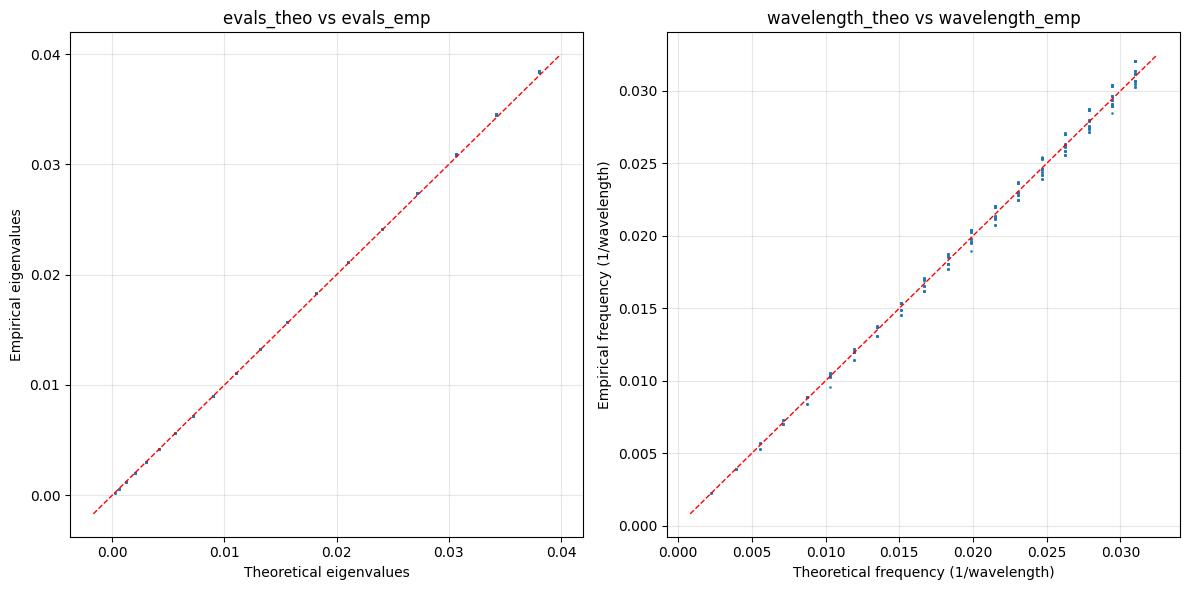

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].scatter(evals_theo, evals_emp, s=1, alpha=0.8)
axs[0].plot(axs[0].get_xlim(), axs[0].get_xlim(), "r--", linewidth=1)

axs[0].set_xlabel("Theoretical eigenvalues")
axs[0].set_ylabel("Empirical eigenvalues")
axs[0].set_title("evals_theo vs evals_emp")
axs[0].grid(True, alpha=0.3)

axs[1].scatter(1/wavelength_theo,1/wavelength_emp, s=1, alpha=0.8)
axs[1].plot(axs[1].get_xlim(), axs[1].get_xlim(), "r--", linewidth=1)

axs[1].set_xlabel("Theoretical frequency (1/wavelength)")
axs[1].set_ylabel("Empirical frequency (1/wavelength)")
axs[1].set_title("wavelength_theo vs wavelength_emp")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()